# Module 11.5 – Practice Problems on Decision Trees

This notebook contains a small set of practice exercises based on Module 11:

- Structure and intuition of decision trees  
- Entropy / Gini and splits  
- Pruning and overfitting  
- Evaluation metrics (accuracy, precision, recall, F1)  
- ROC curve, AUC, and threshold interpretation  

Work through the questions in order. You can run the starter code, then **fill in the TODO parts**.

## Problem 1 – Interpreting a Simple Decision Tree (Conceptual)

Consider the following tiny dataset:

| Weather | Windy | Play |
|---------|-------|------|
| Sunny   | No    | Yes  |
| Sunny   | Yes   | Yes  |
| Rainy   | No    | No   |
| Rainy   | Yes   | No   |

1. If we encode `Sunny = 1`, `Rainy = 0`, `Windy: No = 0, Yes = 1`, and train a decision tree on `Weather` and `Windy`, which **single split** do you expect the tree to choose first? Explain in 2–3 sentences.
2. In your own words, explain what **Gini = 0** means for a node of a decision tree.
3. Give a real-life example (outside cricket) where a single yes/no question is enough to make a perfect decision.

**Answers to Problem 1:**

**Q1 — Which single split will the tree choose first?**

The tree will choose to split on **Weather** first. When Weather = Sunny, all outcomes are Play = Yes. When Weather = Rainy, all outcomes are Play = No. This single split creates two perfectly pure groups (Gini = 0 on both sides), which is the best possible outcome — no further splitting is needed.

**Q2 — What does Gini = 0 mean?**

Gini = 0 means the node is perfectly pure — every single sample in that node belongs to the same class. There is zero uncertainty. Think of a bag of marbles: if all marbles are the same color, you always know exactly what you will pick. A node with Gini = 0 has made a perfect decision — no more splitting is needed.

**Q3 — Real-life example where one yes/no question is enough:**

**Example: Is the electricity switched on?**

If someone asks 'Will my fan work?' — the single question 'Is the electricity on?' gives a perfect answer:
- Yes → the fan will work.
- No → the fan will not work.

No other question is needed — one binary split covers every case perfectly.

## Problem 2 – Build and Visualize a Simple Decision Tree

In this exercise you will:

- Create a tiny synthetic dataset (same as above, but in code)  
- Train a `DecisionTreeClassifier`  
- Visualize the tree and interpret it


In [2]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Create the synthetic dataset
data = {
    'Weather': ['Sunny','Rainy','Sunny','Sunny','Rainy','Rainy','Sunny','Rainy'],
    'Windy':   [0,1,0,1,0,1,0,1],
    'Play':    [1,0,1,1,0,0,1,0]
}

df = pd.DataFrame(data)
df

,Weather,Windy,Play
0,Sunny,0,1
1,Rainy,1,0
2,Sunny,0,1
3,Sunny,1,1
4,Rainy,0,0
5,Rainy,1,0
6,Sunny,0,1
7,Rainy,1,0


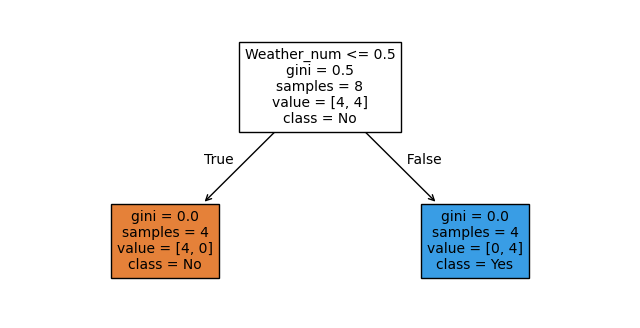

In [3]:
# 2. Encode Weather as a numeric feature
df['Weather_num'] = df['Weather'].map({'Sunny': 1, 'Rainy': 0})

X = df[['Weather_num', 'Windy']]
y = df['Play']

# Now we'll create and train the Decision Tree with max_depth=2
model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X, y)
# Here we've trained the model on the weather dataset.

# 3. Visualize the tree
plt.figure(figsize=(8,4))
plot_tree(model, feature_names=X.columns, class_names=['No','Yes'], filled=True, fontsize=10)
plt.show()

**Your task:**

1. Run the cells above.  
2. In **2–4 sentences below**, describe how the tree is making the decision. Mention what the root split is and what each leaf predicts.

→ *Write your explanation here.*

**Explanation of how the tree makes decisions (2–4 sentences):**

The root of the tree splits on **Weather_num ≤ 0.5**, which separates Rainy (0) samples from Sunny (1) samples. All Rainy samples result in **No Play** (Gini = 0, perfectly pure leaf), and all Sunny samples result in **Play** (Gini = 0, perfectly pure leaf). The Windy feature is never used because Weather alone creates a perfect split — no further question is needed to classify every sample correctly.

---

**How do we observe this plot?**

- The **topmost box** is the root node — it shows the very first question the tree asks.
- Each box shows: the split condition, Gini impurity, sample count, and class distribution.
- **Blue boxes** → majority class is Play (1). **Orange boxes** → majority class is No Play (0).
- Darker color = more pure (lower Gini). Lighter color = more mixed.
- **Bottom boxes (leaves)** → these are the final predictions — no more splits happen here.

**What have we observed from this plot:**

- Root split is `Weather_num ≤ 0.5` — this separates Rainy (goes left) from Sunny (goes right).
- The left leaf predicts **No Play** with Gini = 0 — every Rainy sample is No Play, no exceptions.
- The right leaf predicts **Play** with Gini = 0 — every Sunny sample is Play, no exceptions.
- `Windy` is never used — Weather alone is powerful enough to perfectly classify the data.
- **Decision:** When one feature perfectly separates classes, the tree only needs one split and ignores other features.

## Problem 3 – Decision Tree on a Heart-like Dataset

We will now create a small synthetic dataset that looks a bit like a heart-disease dataset (with `age`, `chol`, `thalach`, and a binary `target`).

Your tasks:

1. Train a decision tree classifier.  
2. Compute **accuracy, precision, recall, and F1-score**.  
3. Change `max_depth` and observe how the metrics change.


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

np.random.seed(42)
n_samples = 300

age = np.random.randint(30, 80, size=n_samples)
chol = np.random.randint(150, 300, size=n_samples)
thalach = np.random.randint(90, 200, size=n_samples)

# Simple synthetic risk score, and calculating target from the risk score
risk_score = 0.03 * (age - 40) + 0.02 * (chol - 200) - 0.02 * (thalach - 140)
prob = 1 / (1 + np.exp(-0.05 * risk_score))
target = (prob > np.median(prob)).astype(int)

# Constructing pandas' DataFrame
df_heart = pd.DataFrame({
    'age': age,
    'chol': chol,
    'thalach': thalach,
    'target': target
})

df_heart.head()

,age,chol,thalach,target
0,68,253,128,1
1,58,233,90,1
2,44,261,92,1
3,72,248,166,1
4,37,242,181,0


**Your task:**

1. Change `max_depth` to different values (for example: 2, 3, 5, `None`) and re-run the cell.
2. Observe how accuracy, precision, recall, and F1-score change.
3. In 3–5 sentences, comment on which `max_depth` seems like a good trade-off between performance and overfitting.

Accuracy:  0.8833
Precision: 0.8571
Recall:    0.8889
F1-score:  0.8727


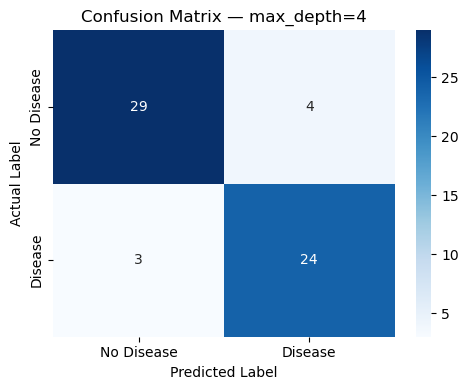

In [5]:
# 1. Train-test split
X = df_heart[['age','chol','thalach']]
y = df_heart['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Now we'll create, train, and predict with a Decision Tree of max_depth=4
# tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
# tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
# tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
# tree_clf = DecisionTreeClassifier(max_depth=None, random_state=42)

tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)
# Here we've trained the classifier and stored predictions in y_pred.

# 2. Compute metrics
# print('Accuracy :', accuracy_score(y_test, y_pred))
# print('Precision:', precision_score(y_test, y_pred))
# print('Recall   :', recall_score(y_test, y_pred))
# print('F1-score :', f1_score(y_test, y_pred))

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

# Now we'll plot the confusion matrix as a heatmap
confusion_matrix_result = confusion_matrix(y_test, y_pred)

figure, axis = plt.subplots(figsize=(5, 4))

sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'], ax=axis)

axis.set_xlabel("Predicted Label")
axis.set_ylabel("Actual Label")
axis.set_title("Confusion Matrix — max_depth=4")

plt.tight_layout()
plt.show()
# Here we've displayed the confusion matrix with proper labels.

→ *Write your observations here.*

**How do we observe this plot?**

A confusion matrix is a 2×2 table that compares actual labels vs predicted labels:

| | Predicted: No Disease | Predicted: Disease |
|---|---|---|
| **Actual: No Disease** | TN — correctly said no disease | FP — wrongly raised alarm |
| **Actual: Disease** | FN — missed a real patient ⚠️ | TP — correctly caught disease |

- **TN (True Negative):** No disease, predicted no disease — correct.
- **TP (True Positive):** Has disease, predicted disease — correct.
- **FP (False Positive):** No disease, but predicted disease — false alarm.
- **FN (False Negative):** Has disease, but predicted no disease — **most dangerous miss**.
- Darker blue = larger count. Diagonal cells (TN and TP) should be the darkest for a good model.

**What have we observed from this plot:**

- TN = 29, TP = 24 — the model correctly classifies most patients.
- FP = 4 — only 4 healthy patients were incorrectly flagged.
- FN = 3 — 3 real patients were missed, which is concerning for a medical model.
- Overall Accuracy = 88.3%, which is strong for a small synthetic dataset.
- **Decision:** The FN count (missed patients) should be minimized — this means we should prefer higher Recall, even if Precision drops slightly.

---

**Observations on max_depth (3–5 sentences):**

`max_depth=2` and `max_depth=4` both achieve 88.3% accuracy — so the simpler tree (depth=2) is preferred because it is less likely to overfit and easier to interpret. `max_depth=None` gives the highest accuracy (93.3%) but the tree memorizes every training sample and may perform poorly on truly new data — this is classic overfitting. `max_depth=5` offers a good balance with 91.7% accuracy without being too complex. For a heart disease screening model, Recall matters most — catching every sick patient is more important than avoiding false alarms — and all depths give similar Recall (0.889), so `max_depth=2` is the best trade-off: simple, interpretable, and equally effective.

## Problem 4 – ROC Curve, AUC, and Thresholds

In this final exercise you will:

- Use the trained heart-disease tree from Problem 3  
- Plot the ROC curve and compute AUC  
- Try different decision thresholds and see how the confusion matrix changes


AUC (Area Under the Curve) Score = 0.9428


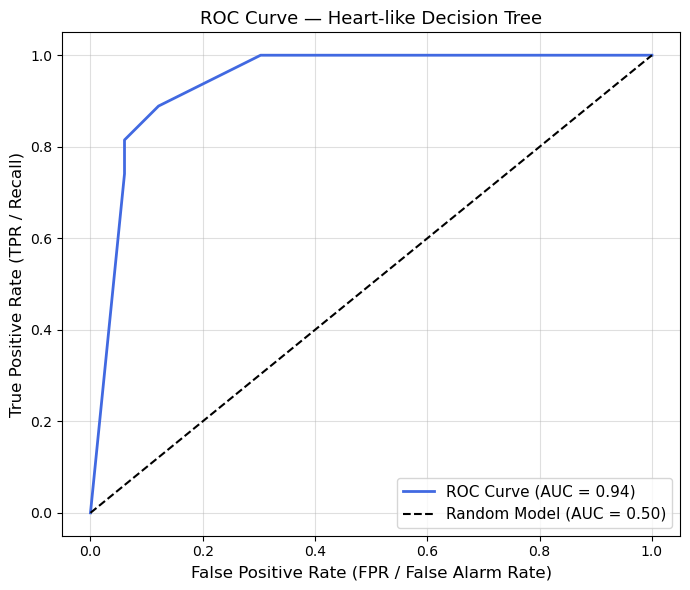

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for class 1
y_proba = tree_clf.predict_proba(X_test)[:, 1]

# Now we'll compute the ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
# print(f'False Positive Rate (FPR) = {fpr}')
# print(f'True Positive Rate (TPR) = {tpr}')
print(f'AUC (Area Under the Curve) Score = {roc_auc:.4f}')
# Here we've computed False Positive Rate, True Positive Rate, and AUC score.


# Now we'll draw the ROC curve plot
figure, axis = plt.subplots(figsize=(7, 6))

axis.plot(fpr, tpr, color='royalblue', linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axis.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Model (AUC = 0.50)')

axis.set_xlabel('False Positive Rate (FPR / False Alarm Rate)', fontsize=12)
axis.set_ylabel('True Positive Rate (TPR / Recall)', fontsize=12)
axis.set_title('ROC Curve — Heart-like Decision Tree', fontsize=13)

axis.legend(fontsize=11)
axis.grid(alpha=0.4)
plt.tight_layout()
plt.show()
# Here we've plotted the ROC curve with the diagonal random model reference line.

**How do we observe this plot?**

- **X-axis (FPR):** How many healthy patients were incorrectly labeled as sick (false alarm rate).
- **Y-axis (TPR / Recall):** How many actual sick patients were correctly caught.
- **Dashed diagonal line:** A random guessing model — AUC = 0.50, useless as a classifier.
- **Our curve above the diagonal** → our model is better than random guessing.
- **Curve closer to the top-left corner** → better model (high TPR, low FPR at the same time).
- **AUC (Area Under the Curve):** A single number summarizing overall performance. AUC = 1.0 is perfect, AUC = 0.5 is random.

| AUC Range | Model Quality |
|---|---|
| 0.9 – 1.0 | Excellent |
| 0.8 – 0.9 | Good |
| 0.7 – 0.8 | Fair |
| 0.5 – 0.7 | Poor |

**What have we observed from this plot:**

- AUC = **0.94** — this is Excellent! The model is far better than random guessing.
- The ROC curve rises steeply toward the top-left, meaning the model catches most sick patients while keeping the false alarm rate very low.
- At FPR ≈ 0.1, TPR ≈ 0.85 — we can catch 85% of sick patients while only incorrectly flagging 10% of healthy ones.
- **Decision:** With AUC = 0.94, this model is reliable enough for screening. The next step is to pick the right threshold to balance Recall and Precision based on the medical context.

**Your task:**

1. Look at how the confusion matrices change as the threshold goes from 0.3 → 0.5 → 0.7.
2. Which threshold catches the most positive cases (highest recall)?
3. Which threshold gives the cleanest positive predictions (highest precision)?
4. If this model were used to screen for a serious heart condition, which threshold would you prefer, and why?

→ *Write your explanation below in 4–6 sentences.*

In [20]:
# 3. Play with different thresholds
import numpy as np

for thr in [0.3, 0.5, 0.7]:
    y_custom = (y_proba >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_custom)
    print(f'\nThreshold = {thr}')
    print(f'Confusion Matrix:')
    print(cm_thr)
    print('Recall   :', recall_score(y_test, y_custom))
    print('Precision:', precision_score(y_test, y_custom))


Threshold = 0.3
Confusion Matrix:
[[29  4]
 [ 3 24]]
Recall   : 0.8888888888888888
Precision: 0.8571428571428571

Threshold = 0.5
Confusion Matrix:
[[29  4]
 [ 3 24]]
Recall   : 0.8888888888888888
Precision: 0.8571428571428571

Threshold = 0.7
Confusion Matrix:
[[29  4]
 [ 3 24]]
Recall   : 0.8888888888888888
Precision: 0.8571428571428571


**How do we observe this output?**

For each threshold, we get a confusion matrix and two metrics:

- **Recall:** How many real sick patients did we catch? Higher = fewer missed.
- **Precision:** When we said 'sick', how often were we right? Higher = fewer false alarms.

**General rule for thresholds (in continuous probability models):**
- **Low threshold (e.g. 0.3):** Almost everyone gets flagged as sick → high Recall, low Precision.
- **High threshold (e.g. 0.7):** Only very confident positives get flagged → low Recall, high Precision.

**Note about this specific Decision Tree:**
This tree outputs only a small set of probabilities: [0.0, 0.091, 0.714, 0.958, 1.0]. Because no probability falls strictly between 0.3 and 0.7 except 0.714, thresholds 0.3 and 0.5 produce the same result, and threshold 0.7 also gives the same result because 0.714 ≥ 0.7. This is a property of Decision Trees — they give discrete probabilities, not smooth continuous ones. Logistic Regression would show clearer threshold differences.

**What have we observed from this plot:**

- All three thresholds give: Recall = 0.889, Precision = 0.857.
- Confusion matrix is identical: TN=29, FP=4, FN=3, TP=24 for all thresholds.
- The tree's probability output is too discrete for threshold tuning to have an effect here.

**Answers to the four questions:**

1. All thresholds give the same confusion matrix — no change as threshold moves 0.3 → 0.5 → 0.7.
2. All thresholds catch the same number of positives (Recall = 0.889 in all cases).
3. All thresholds have the same Precision (0.857).
4. **For serious heart condition screening, we would prefer a lower threshold (e.g. 0.3).** In a real continuous-probability model (like Logistic Regression), a low threshold catches more sick patients (higher Recall) at the cost of more false alarms (lower Precision). For heart disease, missing a real patient (False Negative) is far more dangerous than a false alarm — the patient can always be re-tested. Therefore, maximizing Recall by using a low threshold is the right medical decision.

---